### ADVICE CONDITION

In [17]:
import pandas as pd
import os

df_adv = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "NLP", "results", "docs_topic_weights_reduce_outlier.csv"))
df_adv.head()

,ID,understanding_score,pl1_understanding,pl2_understanding,score_corrected,rank,filename,binary_score,ADVICE,gen,...,assigned_topic,parent_topic_0,parent_topic_1,parent_topic_2,parent_topic_3,parent_topic_4,parent_topic_5,parent_topic_6,parent_topic_7,parent_topic_8
0,557c0bd8fdf99b120dc45dde,0.450602,0.823568,0.077637,0.036000,61,231648_experiment_2024-05-15_18h56.19.209.csv,0.550781,Consider each round carefully as it appears th...,1,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,55cca8f81676ab000ff06ef1,0.046999,0.068651,0.025347,-0.831984,98,977227_experiment_2024-05-15_18h41.00.488.csv,0.562500,"If the multiplier is 5, then choose the pointy...",1,...,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,561f684fed6e5a000dc7e878,-0.011316,-0.072371,0.049740,0.065737,57,517641_experiment_2024-05-15_18h58.56.170.csv,0.550781,The game is fantastic but requires you to thin...,1,...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,56e9c7ac0a5579000d8f7dd4,0.493623,0.967023,0.020224,0.104839,55,187094_experiment_2024-05-15_18h45.57.869.csv,0.546875,My advice would be to pay attention to the col...,1,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,57681fca8e454c000133a203,0.497338,0.941127,0.053548,0.462151,31,621764_experiment_2024-05-15_19h49.20.832.csv,0.566406,"Do not let the timer worry you, but make sure ...",1,...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
from yfiles_jupyter_graphs import GraphWidget

nodes = []
edges = []

for row in df_adv.iterrows():
    ID = row[1]["ID"]
    pID = row[1]["parent_ID"]
    gen = row[1]["gen"]
    topic = row[1]["assigned_topic"]
    rank = row[1]["rank"]
    advice = row[1]["ADVICE"]
    nodes.append(
        {"id": ID, "properties": {"gen": gen, "topic": topic, "label": rank, "advice": advice, "parent_ID": pID}}
    )
    edges.append(
        {"start": pID, "end": ID}
    )
    

node_colors = {}


def custom_style_mapping(index, node):
    color_palette = [
        "#0072B2",  # Blue
        "#E69F00",  # Orange
        "#009E73",  # Green
        "#D55E00",  # Red
        "#CC79A7",  # Purple
        "#A65628",  # Brown
        "#F0E442",  # Yellow
        "#D6C700",  # Yellow-Green
        "#00CFE3"   # Cyan
    ]
    shape_palette = [
        "rectangle",
        "round-rectangle",
        "ellipse",
        "triangle",
        "hexagon",
        "octagon",
        "parallelogram",
        "trapezoid",
        "diamond"
    ]

    topic = node.get("properties", {}).get("topic", 0)  # Default to 0 if missing
    label = node.get("properties", {}).get("label", "")

    

    if topic == -1:
        color = "grey"
        shape = "triangle"  # Note: 'triangle_pointing_right' might not be supported; use 'triangle' or 'right-triangle'
    
    elif topic in [2, 4, 8]:
        color = color_palette[1]
        shape = shape_palette[1]
    elif topic in [0, 1]:
        color = color_palette[0]
        shape = shape_palette[0]
    else:
        color = color_palette[topic % len(color_palette)]  # Protect against overflow
        shape = shape_palette[topic % len(shape_palette)]  # Protect against overflow

    node_colors[node["id"]] = color

    # Return proper style dict
    return {
        "shape": shape,
        "color": color,
        "stroke": "black",  # Optional: for border color
        "label": label,
        "text": advice
    }

def custom_edge_color_mapping(index, edge):
    source_id = edge["start"]  # The starting node ID of this edge
    color = node_colors.get(source_id, "black")  # Default to black if not found
    return color



w = GraphWidget()
w.nodes = nodes
w.edges = edges
w.set_node_styles_mapping(custom_style_mapping)
w.set_edge_color_mapping(custom_edge_color_mapping)
w.directed = True
w.organic_layout()

display(w)

GraphWidget(layout=Layout(height='800px', width='100%'))

### OBSERVATION CONDITION

In [20]:
import pandas as pd
import os

df_obs = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "output", "processed", "data_obs.csv"))
df_obs.head()

,Unnamed: 0,ID,understanding_score,pl1_understanding,pl2_understanding,score_corrected,rank,filename,binary_score,gen,...,parent_understanding_score,parent_pl1_understanding,parent_pl2_understanding,parent_score_corrected,parent_rank,parent_filename,parent_ADVICE,parent_gen,parent_binary_score,parent_n_miss
0,1,575865ba7b74a80006de2689,0.350785,0.902381,-0.200810,0.843750,15,908848_experiment_2024-10-01_09h22.48.378.csv,0.574219,1,...,0.0,0.0,0.0,0.0,0,NaN,NaN,0,NaN,NaN
1,2,575b2b408b705300078ae5e6,0.245500,0.452088,0.038911,-0.047619,71,961729_experiment_2024-10-01_17h19.23.734.csv,0.550781,1,...,0.0,0.0,0.0,0.0,0,NaN,NaN,0,NaN,NaN
2,3,57b76ef5017c2d000166f019,0.109449,0.235450,-0.016551,0.529528,30,223814_experiment_2024-10-01_17h28.15.857.csv,0.605469,1,...,0.0,0.0,0.0,0.0,0,NaN,NaN,0,NaN,NaN
3,4,57ff8c2d90de420001673aa0,0.084324,0.136036,0.032611,0.245098,53,687549_experiment_2024-10-01_17h24.29.298.csv,0.535156,1,...,0.0,0.0,0.0,0.0,0,NaN,NaN,0,NaN,NaN
4,5,5848ad3bdb871400012da095,0.269850,0.474537,0.065162,-0.614583,96,247730_experiment_2024-10-01_10h28.44.942.csv,0.535156,1,...,0.0,0.0,0.0,0.0,0,NaN,NaN,0,NaN,NaN


In [15]:
from yfiles_jupyter_graphs import GraphWidget

nodes = []
edges = []

for row in df_obs.iterrows():
    ID = row[1]["ID"]
    pID = row[1]["parent_ID"]
    gen = row[1]["gen"]
    rank = row[1]["rank"]
    nodes.append(
        {"id": ID, "properties": {"gen": gen, "label": rank, "ID": ID}}
    )
    edges.append(
        {"start": pID, "end": ID}
    )
    

w = GraphWidget()
w.nodes = nodes
w.edges = edges
w.directed = True
w.organic_layout()

display(w)

GraphWidget(layout=Layout(height='800px', width='100%'))

In [6]:
n_grandchild = []
ids = []
for row in df_obs.iterrows():
    id_grandparent = row[1]["ID"]
    df_child = df_obs[df_obs["parent_ID"] == id_grandparent]
    ids.append(id_grandparent)
    for row_child in df_child.iterrows():
        id_parent = row_child[1]["ID"]
        df_grandchild = df_obs[df_obs["parent_ID"] == id_parent]
        n_grandchild.append(len(df_grandchild))

sum(n_grandchild) / len(n_grandchild)

0.8863636363636364

## GRANDCHILDREN METRICS

In [25]:
from scipy.stats import ttest_ind, mannwhitneyu

df_adv['has_children'] = df_adv['ID'].isin(df_adv['parent_ID']).astype(int)
children_counts = df_adv.groupby('parent_ID')['ID'].apply(list).to_dict()
df_adv['grandchildren_count'] = df_adv['ID'].apply(lambda x: sum(df_adv[df_adv['ID'].isin(children_counts.get(x, []))]['has_children']))

df_obs['has_children'] = df_obs['ID'].isin(df_obs['parent_ID']).astype(int)
children_counts = df_obs.groupby('parent_ID')['ID'].apply(list).to_dict()
df_obs['grandchildren_count'] = df_obs['ID'].apply(lambda x: sum(df_obs[df_obs['ID'].isin(children_counts.get(x, []))]['has_children']))

df_adv_test = df_adv.query("rank < 10")
df_obs_test = df_obs.query("rank < 10")

# Compute Mean and Standard Deviation for both conditions
mean_obs, std_obs = df_obs_test['grandchildren_count'].mean(), df_obs_test['grandchildren_count'].std()
mean_adv, std_adv = df_adv_test['grandchildren_count'].mean(), df_adv_test['grandchildren_count'].std()

print(f"Condition ADV - Mean: {mean_adv:.2f}, SD: {std_adv:.2f}")
print(f"Condition OBS - Mean: {mean_obs:.2f}, SD: {std_obs:.2f}")

# Perform an independent t-test (assumes normal distribution)
t_stat, p_value = ttest_ind(df_obs_test['grandchildren_count'], df_adv_test['grandchildren_count'], equal_var=False)

# Perform a Mann-Whitney U test (non-parametric alternative)
u_stat, u_p_value = mannwhitneyu(df_obs_test['grandchildren_count'], df_adv_test['grandchildren_count'], alternative='two-sided')

print(f"T-test: t = {t_stat:.2f}, p = {p_value:.4f}")
print(f"Mann-Whitney U test: U = {u_stat:.2f}, p = {u_p_value:.4f}")

Condition ADV - Mean: 1.58, SD: 1.54
Condition OBS - Mean: 1.19, SD: 1.29
T-test: t = -1.84, p = 0.0675
Mann-Whitney U test: U = 3482.50, p = 0.0928


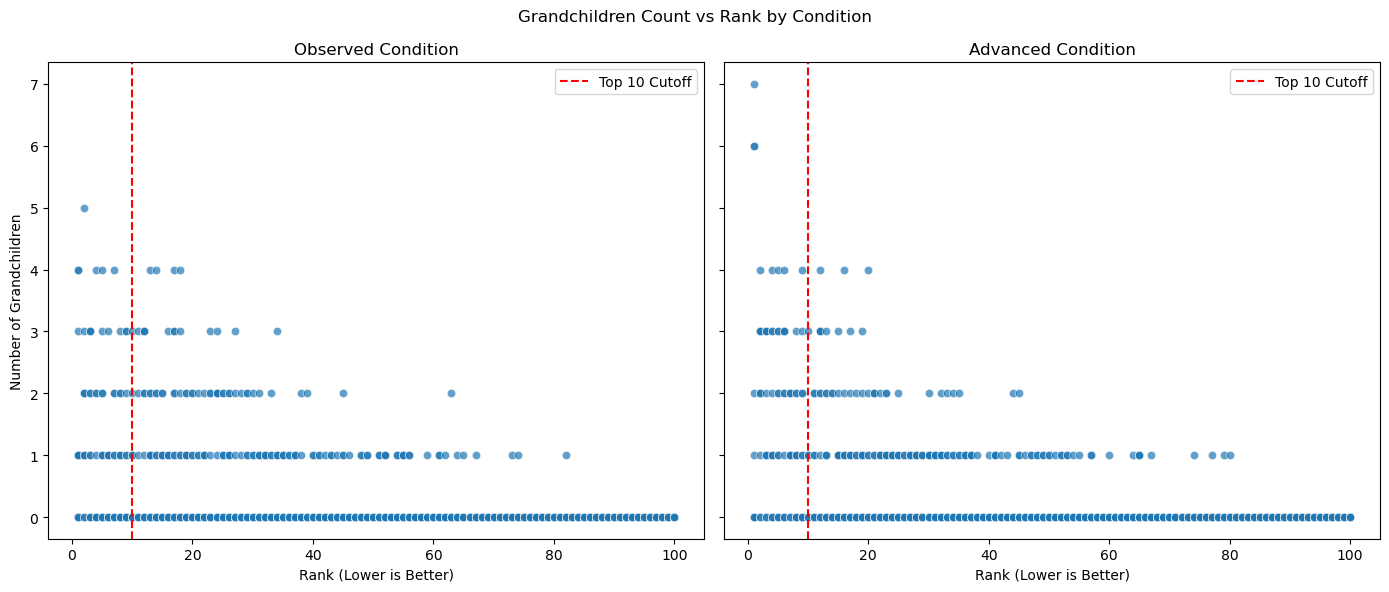

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add condition labels
df_obs['condition'] = 'Observed'
df_adv['condition'] = 'Advanced'

# Sort by rank
df_obs = df_obs.sort_values(by="rank")
df_adv = df_adv.sort_values(by="rank")

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Observed Condition Plot
sns.scatterplot(data=df_obs, x='rank', y='grandchildren_count', alpha=0.7, ax=axes[0])
axes[0].axvline(x=10, color='red', linestyle='--', label="Top 10 Cutoff")
axes[0].set_title("Observed Condition")
axes[0].set_xlabel("Rank (Lower is Better)")
axes[0].set_ylabel("Number of Grandchildren")
axes[0].legend()

# Advanced Condition Plot
sns.scatterplot(data=df_adv, x='rank', y='grandchildren_count', alpha=0.7, ax=axes[1])
axes[1].axvline(x=10, color='red', linestyle='--', label="Top 10 Cutoff")
axes[1].set_title("Advanced Condition")
axes[1].set_xlabel("Rank (Lower is Better)")
axes[1].legend()

plt.suptitle("Grandchildren Count vs Rank by Condition")
plt.tight_layout()
plt.show()


In [37]:
df_obs['condition'] = 'OBS'
df_adv['condition'] = 'ADV'

# Assume 'generation', 'rank', and 'condition' are columns in your dataframe
# Combine df_obs_test and df_adv_test for the analysis
df_combined = pd.concat([df_obs, df_adv])

df_combined.to_csv(os.path.join(os.path.dirname(os.getcwd()), "output", "processed", "df_grandchildren.csv"), header=True, index=False)


## TREE METRICS

In [ ]:
import pandas as pd
import networkx as nx
import os
from lifelines import KaplanMeierFitter
from scipy.stats import ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt

# ---------------------------
# Load your dataset
# ---------------------------

df_obs = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "output", "processed", "data_obs.csv"))
df_adv = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "NLP", "results", "docs_topic_weights_reduce_outlier.csv"))

df_obs["condition"] = "OBS"
df_adv["condition"] = "ADV"

data = pd.concat([df_obs, df_adv])

# ---------------------------
# Build Lineage Graph
# ---------------------------

def build_graph(data):
    G = nx.DiGraph()
    for _, row in data.iterrows():
        G.add_node(row['ID'], generation=row['gen'], score=row['score_corrected'], condition=row['condition'])
        if pd.notna(row['parent_ID']):
            G.add_edge(row['parent_ID'], row['ID'])
    return G

# ---------------------------
# Compute Lineage Metrics
# ---------------------------

def lineage_depth(G, root):
    lengths = nx.single_source_shortest_path_length(G, root)
    return max(lengths.values())

def lineage_size(G, root):
    return len(nx.descendants(G, root))

def branching_factor(G, root):
    lineage_nodes = nx.descendants(G, root) | {root}
    return sum(len(list(G.successors(n))) for n in lineage_nodes) / len(lineage_nodes)

# ---------------------------
# Aggregate Lineage Metrics
# ---------------------------

def analyze_lineages(data, G):
    roots = data.loc[data['parent_ID'].str.startswith('fake '), 'ID'].tolist()
    root_conditions = data.set_index('ID')['condition'].to_dict()
    
    results = []
    for root in roots:
        results.append({
            'root_ID': root,
            'condition': root_conditions[root],
            'lineage_depth': lineage_depth(G, root),
            'lineage_size': lineage_size(G, root),
            'branching_factor': branching_factor(G, root)
        })
    
    return pd.DataFrame(results)

# ---------------------------
# Survival Analysis (Kaplan-Meier)
# ---------------------------

def plot_survival(results):
    kmf = KaplanMeierFitter()

    plt.figure(figsize=(8, 6))
    for condition in results['condition'].unique():
        lifetimes = results.loc[results['condition'] == condition, 'lineage_depth']
        kmf.fit(lifetimes, event_observed=[1] * len(lifetimes), label=f"Condition {condition}")
        kmf.plot_survival_function(ci_show=False)

    plt.title("Lineage Survival by Condition")
    plt.xlabel("Generations (Lineage Depth)")
    plt.ylabel("Survival Probability")
    plt.legend()
    plt.show()

# ---------------------------
# Statistical Tests
# ---------------------------

def compare_conditions(results):
    metrics = ['lineage_depth', 'lineage_size', 'branching_factor']
    conditions = results['condition'].unique()
    if len(conditions) != 2:
        raise ValueError("Currently set up for exactly two conditions.")
    
    cond1, cond2 = conditions
    summary = {}
    for metric in metrics:
        x = results.loc[results['condition'] == cond1, metric]
        y = results.loc[results['condition'] == cond2, metric]
        
        t_stat, t_pval = ttest_ind(x, y, equal_var=False)
        u_stat, u_pval = mannwhitneyu(x, y, alternative='two-sided')
        
        summary[metric] = {
            'mean_{}'.format(cond1): x.mean(),
            'mean_{}'.format(cond2): y.mean(),
            't_test_p': t_pval,
            'u_test_p': u_pval
        }
    return pd.DataFrame(summary).T

# ---------------------------
# Master Function to Run All
# ---------------------------

def run_lineage_analysis(data):
    G = build_graph(data)
    results = analyze_lineages(data, G)
    print("\n=== Summary of Lineage Metrics by Condition ===")
    print(results.groupby('condition')[['lineage_depth', 'lineage_size', 'branching_factor']].mean())
    
    print("\n=== Statistical Comparisons Between Conditions ===")
    stats = compare_conditions(results)
    print(stats)
    
    print("\n=== Plotting Survival Curves ===")
    plot_survival(results)
    
    return results, stats

# ---------------------------
# Example Usage
# ---------------------------

results, stats = run_lineage_analysis(data)

# You can export the results if needed
# results.to_csv("lineage_metrics.csv", index=False)
# stats.to_csv("lineage_stats.csv", index=True)

results

In [ ]:
results["lineage_depth"]
print(results[results["condition"] == "OBS"]["lineage_size"].max())
print(results[results["condition"] == "ADV"]["lineage_size"].max())

## SIMULATION

In [ ]:
import pandas as pd
import numpy as np
import random
random.seed(37)

def create_population(n, gen, parent_info=None):
    """Create a population of agents with random scores and ranks."""
    scores = np.random.normal(0, 1, size=n)
    ids = [f"h_{gen}-{i}" for i in range(n)]
    pop = pd.DataFrame({
        "id": ids,
        "score": scores,
        "gen": gen,
        "rank": pd.Series(scores).rank(method='first', ascending=False)  # Rank the scores
    })

    if parent_info:
        pop["parent_id"], pop["parent_score"], pop["parent_rank"] = parent_info
    return pop

def tournament_selection(pop, k=4):
    """Select a parent using tournament selection from the population."""
    selected_pop = pop.sample(n=k)
    best_parent = pop.loc[selected_pop["score"].idxmax()]
    return best_parent

def transmission_score(parent_scores, transmission_quality):
    """Generate scores based on parent scores and transmission quality."""
    mu = parent_scores * transmission_quality
    return np.random.normal(mu, 1)


def run_simulation(n, n_gen, transmission_quality):
    """Simulate the evolutionary process over multiple generations."""
    # Initial population
    pop = create_population(n, gen=0)

    # Initialize dataframe to store results
    data = pop[["id", "score", "gen", "rank"]].copy()
    data["parent_id"], data["parent_score"], data["parent_rank"] = np.nan, np.nan, np.nan

    # Simulate each generation
    for gen in range(1, n_gen + 1):
        parent_info = [], [], []  # For storing parent data across all agents
        for agent in range(n):
            parent = tournament_selection(pop, k=4)
            parent_info[0].append(parent["id"])  # parent_id
            parent_info[1].append(parent["score"])  # parent_score
            parent_info[2].append(parent["rank"])  # parent_rank

        # Generate new scores for the next generation
        gen_scores = transmission_score(np.array(parent_info[1]), transmission_quality)

        # Create the new generation's DataFrame
        gen_data = create_population(n, gen, parent_info)
        gen_data["score"] = gen_scores
        gen_data["rank"] = gen_data["score"].rank(method='first', ascending=False)

        # Append to the data for all generations
        data = pd.concat([data, gen_data])

        # Set the population for the next generation
        pop = gen_data

    return data



# Parameters
n = 100  # population size
n_gen = 10  # number of generations
transmission_quality = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]  # transmission quality values
n_sim_per_quality = 200  # Number of simulations per transmission quality value

# Initialize a list to store data from all simulations
data_list = []

# Run the simulations for each transmission quality value
for tq in transmission_quality:
    for sim in range(n_sim_per_quality):
        # Run a single simulation with the given transmission quality value
        data_sim = run_simulation(n, n_gen, transmission_quality=tq)
        
        # Add simulation index and transmission quality to the results
        data_sim["sim"] = sim
        data_sim["transmission_quality"] = tq
        
        # Append the results to the data list
        data_list.append(data_sim)

# Concatenate all simulation results into a single DataFrame
data = pd.concat(data_list, ignore_index=True)

In [ ]:
from yfiles_jupyter_graphs import GraphWidget

nodes = []
edges = []

df_graph = data.query("sim == 5")

for row in df_graph.iterrows():
    ID = row[1]["id"]
    pID = row[1]["parent_id"]
    gen = row[1]["gen"]
    rank = row[1]["rank"]
    nodes.append(
        {"id": ID, "properties": {"gen": gen, "label": rank}}
    )
    edges.append(
        {"start": pID, "end": ID}
    )

w = GraphWidget()
w.nodes = nodes
w.edges = edges
w.directed = True
w.organic_layout()

display(w)

In [ ]:
import pandas as pd
import networkx as nx
import os
from lifelines import KaplanMeierFitter
from scipy.stats import ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt

# ---------------------------
# Build Lineage Graph
# ---------------------------

def build_graph(data):
    G = nx.DiGraph()
    for _, row in data.iterrows():
        G.add_node(row['id'], generation=row['gen'], score=row['score'], condition=row['transmission_quality'])
        if pd.notna(row['parent_id']):
            G.add_edge(row['parent_id'], row['id'])
    return G

def lineage_depth(G, root):
    lengths = nx.single_source_shortest_path_length(G, root)
    return max(lengths.values())

def lineage_size(G, root):
    return len(nx.descendants(G, root))

def branching_factor(G, root):
    lineage_nodes = nx.descendants(G, root) | {root}
    return sum(len(list(G.successors(n))) for n in lineage_nodes) / len(lineage_nodes)


def analyze_lineages(data, G):
    roots = data.loc[data['parent_id'].isna(), 'id'].tolist()
    root_conditions = data.set_index('id')['transmission_quality'].to_dict()
    
    results = []
    for root in roots:
        results.append({
            'root_ID': root,
            'condition': root_conditions[root],
            'lineage_depth': lineage_depth(G, root),
            'lineage_size': lineage_size(G, root),
            'branching_factor': branching_factor(G, root)
        })
    
    return pd.DataFrame(results)


# List to store dictionaries with results
lineage_data = []

# Loop over transmission quality values
for tq in transmission_quality:
    df_quality = data.query("transmission_quality == @tq")
    for sim_id in set(df_quality["sim"]):
        df_graph = df_quality.query("sim == @sim_id")
        G = build_graph(df_graph)
        res = analyze_lineages(df_graph, G)
        # Append the result as a dictionary
        lineage_data.append({
            "transmission_quality": tq,
            "sim": sim_id,
            "max_lineage_size": res["lineage_size"].max()
        })

# Convert list of dictionaries to a DataFrame
lineage_df = pd.DataFrame(lineage_data)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))  # Adjust figure size as needed

sns.boxplot(data=lineage_df, x="transmission_quality", y="max_lineage_size", palette="Set2")

plt.xlabel("Transmission Quality", fontsize=12)
plt.ylabel("Max Lineage Size", fontsize=12)
plt.title("Distribution of Max Lineage Size per Transmission Quality", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))  # Set figure size

# Loop through unique transmission qualities and plot KDE for each
for tq in sorted(lineage_df['transmission_quality'].unique()):
    subset = lineage_df[lineage_df['transmission_quality'] == tq]
    sns.kdeplot(
        subset['max_lineage_size'], 
        label=f"TQ: {tq}", 
        fill=True,  # To fill under the curve (optional, for better visualization)
        alpha=0.3  # Transparency of fill
    )

plt.xlabel("Max Lineage Size", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Density Plot of Max Lineage Size per Transmission Quality", fontsize=14)
plt.legend(title="Transmission Quality")
plt.tight_layout()
plt.show()

In [ ]:

# ---------------------------
# Compute Lineage Metrics
# ---------------------------

def lineage_depth(G, root):
    lengths = nx.single_source_shortest_path_length(G, root)
    return max(lengths.values())

def lineage_size(G, root):
    return len(nx.descendants(G, root))

def branching_factor(G, root):
    lineage_nodes = nx.descendants(G, root) | {root}
    return sum(len(list(G.successors(n))) for n in lineage_nodes) / len(lineage_nodes)

# ---------------------------
# Aggregate Lineage Metrics
# ---------------------------

def analyze_lineages(data, G):
    roots = data.loc[data['parent_ID'].str.startswith('fake '), 'ID'].tolist()
    root_conditions = data.set_index('id')['transmission_quality'].to_dict()
    
    results = []
    for root in roots:
        results.append({
            'root_ID': root,
            'condition': root_conditions[root],
            'lineage_depth': lineage_depth(G, root),
            'lineage_size': lineage_size(G, root),
            'branching_factor': branching_factor(G, root)
        })
    
    return pd.DataFrame(results)

# ---------------------------
# Survival Analysis (Kaplan-Meier)
# ---------------------------

def plot_survival(results):
    kmf = KaplanMeierFitter()

    plt.figure(figsize=(8, 6))
    for condition in results['condition'].unique():
        lifetimes = results.loc[results['condition'] == condition, 'lineage_depth']
        kmf.fit(lifetimes, event_observed=[1] * len(lifetimes), label=f"Condition {condition}")
        kmf.plot_survival_function(ci_show=False)

    plt.title("Lineage Survival by Condition")
    plt.xlabel("Generations (Lineage Depth)")
    plt.ylabel("Survival Probability")
    plt.legend()
    plt.show()

# ---------------------------
# Statistical Tests
# ---------------------------

def compare_conditions(results):
    metrics = ['lineage_depth', 'lineage_size', 'branching_factor']
    conditions = results['condition'].unique()
    if len(conditions) != 2:
        raise ValueError("Currently set up for exactly two conditions.")
    
    cond1, cond2 = conditions
    summary = {}
    for metric in metrics:
        x = results.loc[results['condition'] == cond1, metric]
        y = results.loc[results['condition'] == cond2, metric]
        
        t_stat, t_pval = ttest_ind(x, y, equal_var=False)
        u_stat, u_pval = mannwhitneyu(x, y, alternative='two-sided')
        
        summary[metric] = {
            'mean_{}'.format(cond1): x.mean(),
            'mean_{}'.format(cond2): y.mean(),
            't_test_p': t_pval,
            'u_test_p': u_pval
        }
    return pd.DataFrame(summary).T

# ---------------------------
# Master Function to Run All
# ---------------------------

def run_lineage_analysis(data):
    G = build_graph(data)
    results = analyze_lineages(data, G)
    print("\n=== Summary of Lineage Metrics by Condition ===")
    print(results.groupby('condition')[['lineage_depth', 'lineage_size', 'branching_factor']].mean())
    
    print("\n=== Statistical Comparisons Between Conditions ===")
    stats = compare_conditions(results)
    print(stats)
    
    print("\n=== Plotting Survival Curves ===")
    plot_survival(results)
    
    return results, stats

# ---------------------------
# Example Usage
# ---------------------------

results, stats = run_lineage_analysis(data)

# You can export the results if needed
# results.to_csv("lineage_metrics.csv", index=False)
# stats.to_csv("lineage_stats.csv", index=True)

results

In [ ]:

nodes = []
edges = []

df_graph = data.query("sim" == 1)

for row in df_graph.iterrows():
    ID = row[1]["id"]
    pID = row[1]["parent_id"]
    gen = row[1]["gen"]
    rank = row[1]["rank"]
    nodes.append(
        {"id": ID, "properties": {"gen": gen, "label": rank}}
    )
    edges.append(
        {"start": pID, "end": ID}
    )
    

w = GraphWidget()
w.nodes = nodes
w.edges = edges
w.directed = True
w.organic_layout()

display(w)

In [ ]:

# --------- Plotting ---------

# Set style
sns.set(style="whitegrid")

# Plot population score distribution
plt.figure(figsize=(12, 6))
sns.histplot(pop["score"], kde=True, color='skyblue', label='Population Scores', bins=20)
sns.histplot(parent_scores, kde=True, color='orange', label='Selected Parent Scores', bins=10)
plt.legend()
plt.title("Distribution of Population Scores vs. Selected Parent Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(14, 6))
plt.hist(parent_ranks)
plt.xlabel("Selected Parents rank")
plt.ylabel("n")
plt.title("Histogram of ranks of selected parents")
plt.show

## GRAPH METRICS

#### Inclusive fitness

In [46]:
import networkx as nx
import numpy as np

def build_graph(data):
    G = nx.DiGraph()
    for _, row in data.iterrows():
        G.add_node(row['ID'], gen=row['gen'], score=row['score_corrected'])
        if pd.notna(row['parent_ID']):
            G.add_edge(row['parent_ID'], row['ID'])
    return G

def compute_inclusive_fitness(graph, node, depth=1):
    fitness = len(list(graph.successors(node))) * (0.5 ** (depth - 1))  # Weight by generation
    for child in graph.successors(node):
        fitness += compute_inclusive_fitness(graph, child, depth + 1)
    return fitness

data = df_adv

G = build_graph(data)

root_node = [node for node in G.nodes if G.in_degree(node) == 0]
fitness_results = {}
for root in root_node:
    fitness_results[root] = compute_inclusive_fitness(G, root)



fitness_values = list(fitness_results.values())
mean_fitness = np.mean(fitness_values)
std_fitness = np.std(fitness_values)

print(f"Mean Inclusive Fitness: {mean_fitness:.4f}")
print(f"Standard Deviation: {std_fitness:.4f}")

Mean Inclusive Fitness: 1.9980
Standard Deviation: 1.7267


In [52]:
data.query("gen == 1")

,ID,understanding_score,pl1_understanding,pl2_understanding,score_corrected,rank,filename,binary_score,ADVICE,gen,...,assigned_topic,parent_topic_0,parent_topic_1,parent_topic_2,parent_topic_3,parent_topic_4,parent_topic_5,parent_topic_6,parent_topic_7,parent_topic_8
0,557c0bd8fdf99b120dc45dde,0.450602,0.823568,0.077637,0.036000,61,231648_experiment_2024-05-15_18h56.19.209.csv,0.550781,Consider each round carefully as it appears th...,1,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,55cca8f81676ab000ff06ef1,0.046999,0.068651,0.025347,-0.831984,98,977227_experiment_2024-05-15_18h41.00.488.csv,0.562500,"If the multiplier is 5, then choose the pointy...",1,...,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,561f684fed6e5a000dc7e878,-0.011316,-0.072371,0.049740,0.065737,57,517641_experiment_2024-05-15_18h58.56.170.csv,0.550781,The game is fantastic but requires you to thin...,1,...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,56e9c7ac0a5579000d8f7dd4,0.493623,0.967023,0.020224,0.104839,55,187094_experiment_2024-05-15_18h45.57.869.csv,0.546875,My advice would be to pay attention to the col...,1,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,57681fca8e454c000133a203,0.497338,0.941127,0.053548,0.462151,31,621764_experiment_2024-05-15_19h49.20.832.csv,0.566406,"Do not let the timer worry you, but make sure ...",1,...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,663827f44936c1ad8d008b68,0.014853,0.029705,0.000000,-0.038934,66,819992_experiment_2024-05-15_18h51.19.608.csv,0.503906,"As each gnome appears, tap S for the left gnom...",1,...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,663b7ad234b11a3aa63c6685,-0.036497,0.149442,-0.222435,-0.151709,73,622208_experiment_2024-05-15_18h41.01.009.csv,0.496094,The gnomes with the long head seems to have hi...,1,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,6640edf60de1f01b4cc686dd,0.552736,0.838690,0.266782,-0.107422,71,194791_experiment_2024-05-15_18h57.00.099.csv,0.542969,"This game is confusing, and I could not see a ...",1,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,6643dcdaee723e90ec897171,0.253084,0.449802,0.056366,0.668000,21,558862_experiment_2024-05-15_13h14.04.274.csv,0.578125,Try not to let your mind wander or you will no...,1,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
gen_stats = {}
for i in range(1, 11):
    root_node = data.query("gen == @i")["parent_ID"].to_list()
    fitness_results = {}
    for root in root_node:
        fitness_results[root] = compute_inclusive_fitness(G, root)
    gen_stats[i] = {"res": fitness_results}